In [1]:
import pandas as pd

df = pd.read_csv(
    "../../../data/primary/crop_recommendation_combined.csv"
)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,soil,crop_label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,unknown,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,unknown,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,unknown,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,unknown,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,unknown,rice


In [2]:
# =====================================================
# Filter hanya komoditas Final Project
# =====================================================

df = df[
    df["crop_label"].isin(
        [
            "rice",
            "maize",
            "cassava",
        ]
    )
].reset_index(drop=True)

print(df["crop_label"].value_counts())

crop_label
rice       200
maize      200
cassava    100
Name: count, dtype: int64


In [3]:
#feature dan target
X = df.drop(
    columns=["crop_label"]
)

y = df["crop_label"]

In [4]:
from sklearn.model_selection import train_test_split

# encoding dulu
X = pd.get_dummies(
    X,
    columns=["soil"],
    dtype=int
)

# baru split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
for col in X.select_dtypes(include="object").columns:
    print(col)
    print(X[col].unique()[:10])
    print("-"*30)

In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   N                500 non-null    int64  
 1   P                500 non-null    int64  
 2   K                500 non-null    int64  
 3   temperature      500 non-null    float64
 4   humidity         500 non-null    float64
 5   ph               500 non-null    float64
 6   rainfall         500 non-null    float64
 7   soil_clay        500 non-null    int64  
 8   soil_sandy loam  500 non-null    int64  
 9   soil_unknown     500 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 39.2 KB


In [7]:
print(X_train.shape)
print(X_train.dtypes.unique())

(400, 10)
[dtype('int64') dtype('float64')]


In [8]:
X_train.select_dtypes(
    include=["object", "string"]
).columns

Index([], dtype='str')

In [9]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Hitung permutation importance
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"   # karena Crop Recommendation adalah klasifikasi
)

# DataFrame importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance,std
0,N,0.083,0.020761
1,P,0.000,0.000000
2,K,0.000,0.000000
3,temperature,0.000,0.000000
4,humidity,0.000,0.000000
5,ph,0.000,0.000000
6,rainfall,0.000,0.000000
7,soil_clay,0.000,0.000000
8,soil_sandy loam,0.000,0.000000
9,soil_unknown,0.000,0.000000


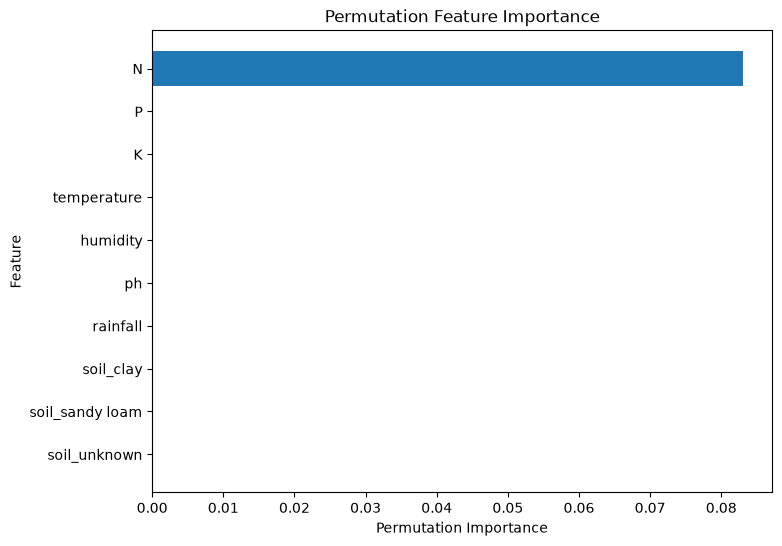

In [11]:
#visualisasi
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [12]:
#prediksi 
y_pred = rf.predict(X_test)

In [13]:
#akurasi
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 1.0000


In [14]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     cassava       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        40
        rice       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [15]:
#cross validation and kfold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

print(scores)
print("Mean Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


Model : Random Forest Classifier
Accuracy      : 100%
CV Accuracy   : 100%

In [17]:
#simpan model
from pathlib import Path
import joblib

ROOT_DIR = Path.cwd().parents[2]

MODEL_DIR = ROOT_DIR / "models" / "crop_recommendation"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    rf,
    MODEL_DIR / "crop_recommendation_rf.pkl"
)

print("Model berhasil disimpan di:")
print(MODEL_DIR / "crop_recommendation_rf.pkl")

Model berhasil disimpan di:
c:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\models\crop_recommendation\crop_recommendation_rf.pkl


In [18]:
from pathlib import Path
import joblib

ROOT_DIR = Path.cwd().parents[2]

MODEL_DIR = ROOT_DIR / "models" / "crop_recommendation"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    X.columns.tolist(),
    MODEL_DIR / "crop_recommendation_features.pkl"
)

print("Features berhasil disimpan.")

Features berhasil disimpan.


In [19]:
from pathlib import Path
import joblib

ROOT_DIR = Path.cwd().parents[2]

CROP_MODEL_DIR = ROOT_DIR / "models" / "crop_recommendation"

CROP_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(CROP_MODEL_DIR)

joblib.dump(
    rf.classes_.tolist(),
    CROP_MODEL_DIR / "crop_labels.pkl"
)

c:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\models\crop_recommendation


['c:\\Users\\hilmi\\Documents\\Dibimbing\\Final Project\\Project\\menanam-ai\\models\\crop_recommendation\\crop_labels.pkl']

Crop Recommendation System

Mengembangkan sistem rekomendasi tanaman berbasis machine learning menggunakan data kandungan unsur hara (N, P, K), kondisi iklim (suhu, kelembapan, curah hujan), pH tanah, dan jenis tanah.

Model Random Forest Classifier berhasil mencapai:
Accuracy: 100%
Mean Cross Validation Accuracy (5-Fold): 100%

Hasil analisis menunjukkan unsur hara Nitrogen paling berpengaruh untuk menghasilkan rekomendasi tanaman.